# AI Brand Search Popularity by Country

This notebook explores country-level AI brand search data from the project CSV. It uses each country's existing rank to compare the top two brands, identify country leaders, and summarize search share. The worldwide (`WW`) row is excluded from all country-level analysis.

## Load the data

The CSV is stored in `data/popularity/csv/`. The path check below supports running the notebook from either the repository root or the `notebooks` folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("data/popularity/csv/popularity-ai-summary.csv")
if not csv_path.exists():
    csv_path = Path("../data/popularity/csv/popularity-ai-summary.csv")

if not csv_path.exists():
    raise FileNotFoundError("Could not find data/popularity/csv/popularity-ai-summary.csv")

df = pd.read_csv(csv_path)
df.head()

,snapshot,category,scope,rank,brand,vendor,avg_monthly_searches,share_pct,mom_pct,yoy_pct
0,2026-07,ai,WW,1,ChatGPT,OpenAI,776290000,82.7,-6.4,26.4
1,2026-07,ai,WW,2,Gemini,Google,103228000,11.0,-9.1,542.5
2,2026-07,ai,WW,3,Claude,Anthropic,17066000,1.8,-2.2,995.6
3,2026-07,ai,WW,4,Grok,xAI,12337000,1.3,-19.1,38.0
4,2026-07,ai,WW,5,Perplexity,Perplexity AI,12140000,1.3,-19.4,-43.5


## Basic data inspection

Check the dataset size, fields, data types, missing values, and the number of scopes and brands. The scope count includes `WW`; the country count does not.

In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Country scopes (excluding WW): {df.loc[df['scope'] != 'WW', 'scope'].nunique()}")
print(f"All scopes (including WW): {df['scope'].nunique()}")
print(f"Brands: {df['brand'].nunique()}")

Rows: 273
Columns: 10
Country scopes (excluding WW): 20
All scopes (including WW): 21
Brands: 13


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("Missing values by column:")
display(df.isna().sum())

Columns:
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

Data types:


snapshot                    str
category                    str
scope                       str
rank                      int64
brand                       str
vendor                      str
avg_monthly_searches      int64
share_pct               float64
mom_pct                 float64
yoy_pct                 float64
dtype: object

Missing values by column:


snapshot                0
category                0
scope                   0
rank                    0
brand                   0
vendor                  0
avg_monthly_searches    0
share_pct               0
mom_pct                 0
yoy_pct                 0
dtype: int64

## Filter to country-level data

Keep a separate copy without the worldwide row. All tables and charts below use this country-level dataframe.

In [4]:
country_df = df[df["scope"] != "WW"].copy()

print(f"Country-level rows: {len(country_df)}")
print(f"WW rows in country_df: {(country_df['scope'] == 'WW').sum()}")

Country-level rows: 260
WW rows in country_df: 0


## Top 4 brands by country

Use the existing `rank` field to select ranks 1 and 2 in each country. The table includes search-share and trend fields from the source CSV.

In [5]:
top4 = country_df[country_df["rank"] <= 4].copy()
top4 = top4.sort_values(["scope", "rank"])

top4_table = top4[
    [
        "scope",
        "rank",
        "brand",
        "vendor",
        "share_pct",
        "avg_monthly_searches",
        "mom_pct",
        "yoy_pct",
    ]
]
display(top4_table.reset_index(drop=True))

,scope,rank,brand,vendor,share_pct,avg_monthly_searches,mom_pct,yoy_pct
0,AU,1,ChatGPT,OpenAI,90.1,16600000,0.0,22.1
1,AU,2,Claude,Anthropic,3.0,550000,-18.7,1009.1
2,AU,3,Gemini,Google,2.4,450000,-18.3,233.3
3,AU,4,Grok,xAI,1.6,301000,-18.3,22.4
4,BR,1,ChatGPT,OpenAI,91.6,83100000,0.0,22.2
...,...,...,...,...,...,...,...,...
75,US,4,Grok,xAI,2.0,2740000,-18.2,22.4
76,VN,1,ChatGPT,OpenAI,79.0,9140000,-32.8,22.2
77,VN,2,Gemini,Google,8.6,1000000,-18.7,395.9
78,VN,3,Grok,xAI,3.9,450000,-18.2,22.3


## Search share for the Top 4 in each country

The grouped bars compare rank 1 through rank 4 brands within every country. Country names are arranged alphabetically and angled to keep all labels readable.

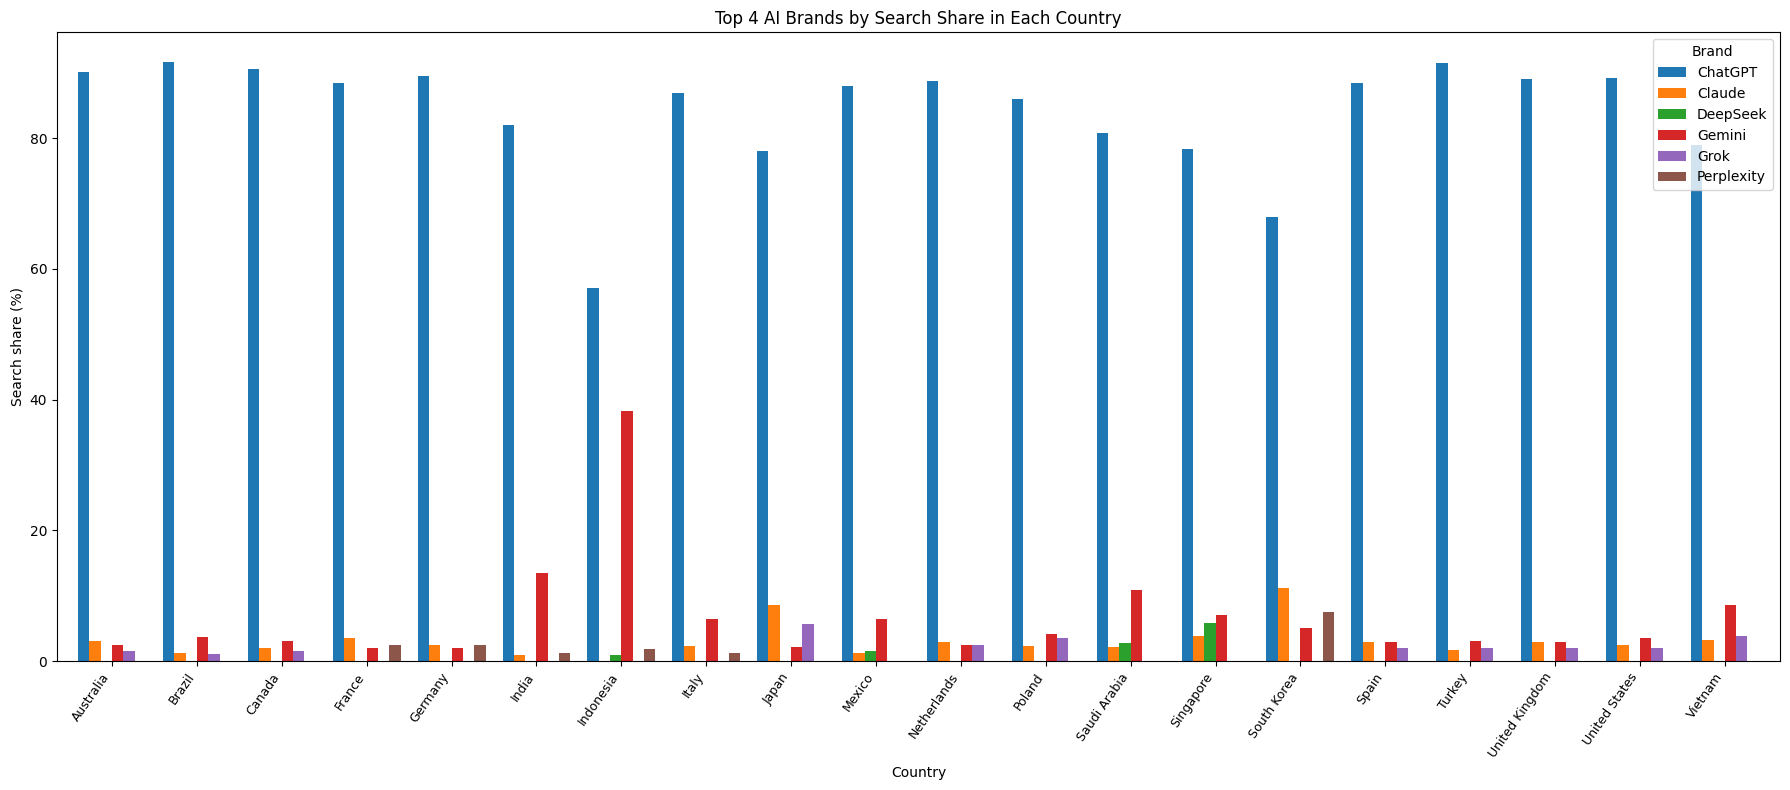

In [6]:
share_by_country = top4.pivot_table(
    index="scope",
    columns="brand",
    values="share_pct",
    aggfunc="first",
    fill_value=0,
).sort_index()

country_names = {
    "AU": "Australia",
    "BR": "Brazil",
    "CA": "Canada",
    "DE": "Germany",
    "ES": "Spain",
    "FR": "France",
    "GB": "United Kingdom",
    "ID": "Indonesia",
    "IN": "India",
    "IT": "Italy",
    "JP": "Japan",
    "KR": "South Korea",
    "MX": "Mexico",
    "NL": "Netherlands",
    "PL": "Poland",
    "SA": "Saudi Arabia",
    "SG": "Singapore",
    "TR": "Turkey",
    "US": "United States",
    "VN": "Vietnam",
}
unknown_scopes = share_by_country.index.difference(country_names)
if not unknown_scopes.empty:
    raise ValueError(f"Missing country names for scopes: {unknown_scopes.tolist()}")
share_by_country = share_by_country.rename(index=country_names).sort_index()

ax = share_by_country.plot(kind="bar", figsize=(18, 8), width=0.8)
ax.set_title("Top 4 AI Brands by Search Share in Each Country")
ax.set_xlabel("Country")
ax.set_ylabel("Search share (%)")
ax.legend(title="Brand")
ax.tick_params(axis="x", labelrotation=55, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.show()

## Average search share among Top 4 appearances

This chart shows each brand's average search share across only the countries where it appears in the Top 4. It is not an average across every country.

,average_share_pct
brand,
ChatGPT,84.060000
Gemini,6.520000
Claude,3.205263
Perplexity,2.783333
DeepSeek,2.775000
Grok,2.527273


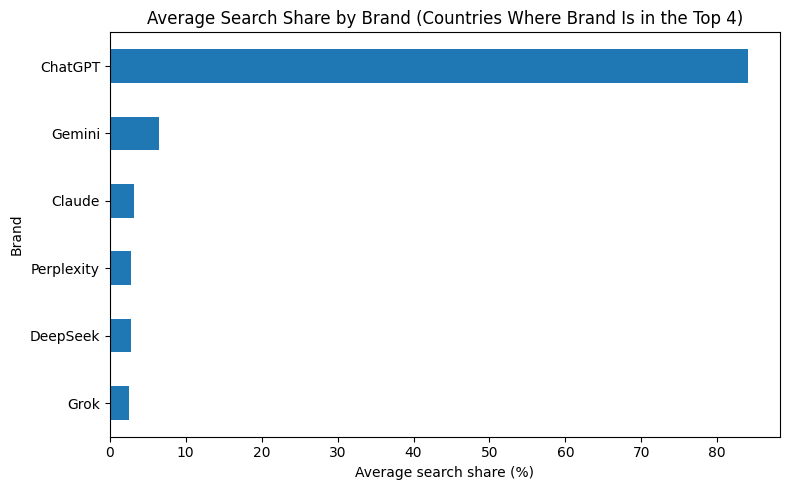

In [7]:
average_top4_share = (
    top4.groupby("brand")["share_pct"]
    .mean()
    .sort_values(ascending=False)
)
display(average_top4_share.rename("average_share_pct").to_frame())

ax = average_top4_share.sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_title("Average Search Share by Brand (Countries Where Brand Is in the Top 4)")
ax.set_xlabel("Average search share (%)")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

## Insights

- **ChatGPT leads all 20 country scopes** in the dataset (rank 1).
- **Brazil has the largest Top-1 share** at 91.6% (ChatGPT).
- **Indonesia has the closest Top-1/Top-2 comparison**: ChatGPT has 57.1% and Gemini has 38.2%, a difference of 18.9 percentage points.
- In the Top 4, **ChatGPT and Gemini each appear in 20 countries, Claude in 19, and Grok in 11**.

These are descriptive observations from this CSV snapshot; they do not explain the causes of the differences.


**This analysis looks good but there is an issue. There can be a place where chatgpt may be falsly be ranked 1 without calculating due to manual calculation error. To minimize this error we can use ML tools to verify the ranking**. 

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Composite Leadership Score without Rank

leader_df = country_df.copy()

def minmax(s):
    min_v = s.min()
    max_v = s.max()
    
    if max_v == min_v:
        return pd.Series(1.0, index=s.index)
    
    return (s - min_v) / (max_v - min_v)


# Normalize each factor within each country
leader_df["share_score"] = (
    leader_df.groupby("scope")["share_pct"]
    .transform(minmax)
)

leader_df["mom_score"] = (
    leader_df.groupby("scope")["mom_pct"]
    .transform(minmax)
)

leader_df["yoy_score"] = (
    leader_df.groupby("scope")["yoy_pct"]
    .transform(minmax)
)


# Weighted leadership score
leader_df["leader_score"] = (
    0.50 * leader_df["share_score"]
    + 0.20 * leader_df["mom_score"]
    + 0.30 * leader_df["yoy_score"]
)


# Select the highest-scoring brand in each country
country_leaders = (
    leader_df.loc[
        leader_df.groupby("scope")["leader_score"].idxmax()
    ]
    .sort_values("scope")
    .reset_index(drop=True)
)

country_leaders[
    ["scope", "brand", "share_pct", "mom_pct", "yoy_pct", "leader_score"]
]

In [14]:
leader_df["leader_score"] = (
    0.30 * leader_df["rank_score"]
    + 0.40 * leader_df["share_score"]
    + 0.10 * leader_df["mom_score"]
    + 0.20 * leader_df["yoy_score"]
)

In [18]:
country_leaders = (
    leader_df
    .sort_values(
        ["scope", "leader_score"],
        ascending=[True, False]
    )
    .groupby("scope")
    .first()
    .reset_index()
)

In [19]:
country_leaders[
    [
        "scope",
        "brand",
        "share_pct",
        "mom_pct",
        "yoy_pct",
        "leader_score"
    ]
].sort_values("scope")

,scope,brand,share_pct,mom_pct,yoy_pct,leader_score
0,AU,ChatGPT,90.1,0.0,22.1,0.761179
1,BR,ChatGPT,91.6,0.0,22.2,0.767737
2,CA,ChatGPT,90.6,0.0,22.1,0.763362
3,DE,ChatGPT,89.5,22.1,49.0,0.778351
4,ES,ChatGPT,88.4,-18.1,22.1,0.739344
5,FR,ChatGPT,88.4,-18.3,49.0,0.741382
6,GB,ChatGPT,89.1,-18.1,0.0,0.740596
7,ID,ChatGPT,57.1,-18.2,0.0,0.600779
8,IN,ChatGPT,82.0,0.0,49.7,0.728061
9,IT,ChatGPT,86.9,-18.1,22.9,0.732859


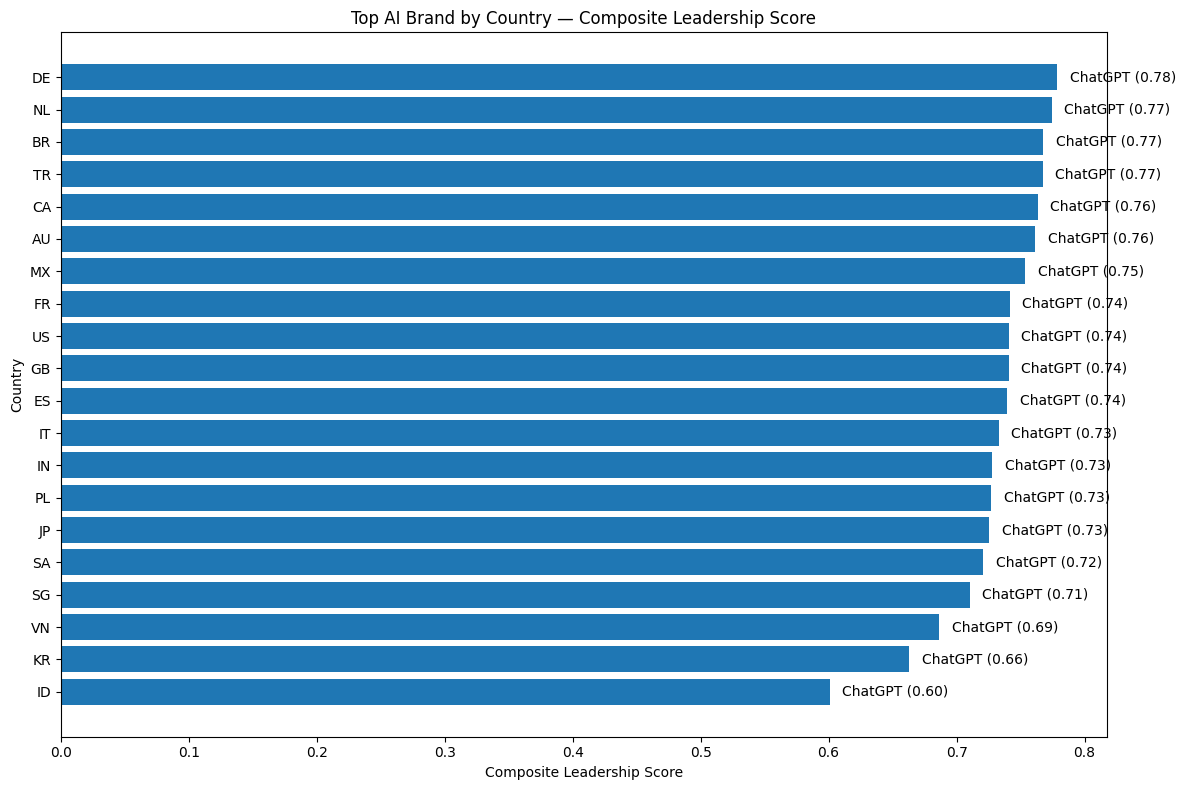

In [20]:
# Top AI Brand by Country — Composite Leadership Score

plot_df = country_leaders.sort_values("leader_score", ascending=True)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["scope"],
    plot_df["leader_score"]
)

plt.xlabel("Composite Leadership Score")
plt.ylabel("Country")
plt.title("Top AI Brand by Country — Composite Leadership Score")

# Add the winning brand and score to each bar
for bar, brand, score in zip(
    bars,
    plot_df["brand"],
    plot_df["leader_score"]
):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{brand} ({score:.2f})",
        va="center"
    )

plt.tight_layout()
plt.show()